# Exploratory Data Analysis — NYC Yellow Taxi Trips (May 2022)

This notebook is a first EDA pass for the **Taxi Fare & Duration Prediction** project (see `AGENTS.md`): predicting a trip's fare and duration using only information that would be available *before* the ride starts, from a public dataset of NYC yellow taxi trips.

**Scope of this pass:** a single month, May 2022. The goal is to understand data quality, agree on a provisional "ordinary trip" baseline for modeling, and confirm which columns are safe to use as prediction inputs versus which ones leak post-trip information.

**Data:**
- Trip records: `data/raw/yellow_tripdata_2022-05.parquet`, pulled with `uv run pull_trip_data --from 2022-05 --to 2022-05` (see the project `README.md`).
- Zone lookup: `data/raw/taxi_zone_lookup.csv`, downloaded automatically by this notebook if it isn't already present.
- Column definitions: `data/data_dictionary_trip_records_yellow.pdf`.

**A note on scope:** all filtering below is exploratory. Nothing is written back to the raw files, and the proposed baseline is meant as a starting point for team review, not a final decision.

## Table of Contents
1. [Load the Dataset](#1-load-the-dataset)
2. [Dataset Overview and Missing Values](#2-dataset-overview-and-missing-values)
3. [Deriving the Duration Target](#3-deriving-the-duration-target)
4. [Data Quality Checks](#4-data-quality-checks)
5. [Building an Ordinary-Trip Baseline](#5-building-an-ordinary-trip-baseline)
6. [Distance and Speed Outliers](#6-distance-and-speed-outliers)
7. [Baseline Filtering Summary](#7-baseline-filtering-summary)
8. [Time-of-Day Patterns](#8-time-of-day-patterns)
9. [Day-of-Week Patterns](#9-day-of-week-patterns)
10. [Distance, Duration, and Fare Relationships](#10-distance-duration-and-fare-relationships)
11. [Pickup and Drop-off Locations](#11-pickup-and-drop-off-locations)
12. [Train, Validation, and Test Split](#12-train-validation-and-test-split)
13. [Modeling Plan: Targets, Features, and Evaluation](#13-modeling-plan-targets-features-and-evaluation)
14. [Summary and Next Steps](#14-summary-and-next-steps)

## 1. Load the Dataset

In [1]:
from pathlib import Path
import pandas as pd

# Locate the dataset from either the project root or notebooks folder.
root = Path.cwd()
if not (root / "pyproject.toml").exists():
    root = root.parent

data_path = root / "data" / "raw" / "yellow_tripdata_2022-05.parquet"
df = pd.read_parquet(data_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
df.head()

Rows: 3,588,295
Columns: 19


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2022-05-01 00:00:36,2022-05-01 00:19:18,1.0,4.1,1.0,N,246,151,2,17.0,3.0,0.5,0.00,0.0,0.3,20.80,2.5,0.0
1,1,2022-05-01 00:27:44,2022-05-01 00:41:33,1.0,2.3,1.0,N,238,74,2,11.0,3.0,0.5,0.00,0.0,0.3,14.80,2.5,0.0
2,1,2022-05-01 00:59:00,2022-05-01 01:14:22,1.0,4.2,1.0,N,163,260,2,15.5,3.0,0.5,0.00,0.0,0.3,19.30,2.5,0.0
3,1,2022-05-01 00:48:18,2022-05-01 01:28:02,1.0,0.0,1.0,N,79,182,1,41.2,0.0,0.5,0.00,0.0,0.3,42.00,0.0,0.0
4,1,2022-05-01 00:28:26,2022-05-01 00:37:49,1.0,1.6,1.0,N,238,75,1,7.5,3.0,0.5,2.25,0.0,0.3,13.55,2.5,0.0


## 2. Dataset Overview and Missing Values

In [2]:
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

column_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
})

display(column_summary.sort_values("missing_count", ascending=False))

Rows: 3,588,295
Columns: 19


,data_type,missing_count,missing_percent
store_and_fwd_flag,str,129524,3.61
RatecodeID,float64,129524,3.61
passenger_count,float64,129524,3.61
airport_fee,float64,129524,3.61
congestion_surcharge,float64,129524,3.61
VendorID,int64,0,0.00
tpep_pickup_datetime,datetime64[us],0,0.00
tpep_dropoff_datetime,datetime64[us],0,0.00
DOLocationID,int64,0,0.00
PULocationID,int64,0,0.00


In [3]:
missing_columns = [
    "store_and_fwd_flag",
    "RatecodeID",
    "passenger_count",
    "airport_fee",
    "congestion_surcharge",
]

missing_mask = df[missing_columns].isna()

missing_patterns = pd.Series({
    "All five fields missing": missing_mask.all(axis=1).sum(),
    "Only some of these fields missing": (
        missing_mask.any(axis=1) & ~missing_mask.all(axis=1)
    ).sum(),
    "None of these fields missing": (~missing_mask.any(axis=1)).sum(),
}, name="trip_count")

display(missing_patterns.to_frame())

,trip_count
All five fields missing,129524
Only some of these fields missing,0
None of these fields missing,3458771


The dataset contains 3,588,295 trips. Five fields are missing together on 129,524 trips (3.61%); no rows have only some of these fields missing. These records are retained pending further investigation.

## 3. Deriving the Duration Target

In [4]:
# Calculate our duration target in minutes.
df["duration_minutes"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

display(
    df[["tpep_pickup_datetime", "tpep_dropoff_datetime"]]
    .agg(["min", "max"])
)

display(
    df[["duration_minutes", "trip_distance", "fare_amount"]]
    .describe(percentiles=[0.01, 0.50, 0.95, 0.99])
    .T
)

,tpep_pickup_datetime,tpep_dropoff_datetime
min,2003-01-01 00:06:06,2003-01-01 00:31:38
max,2022-06-01 23:55:30,2022-06-02 00:03:51


,count,mean,std,min,1%,50%,95%,99%,max
duration_minutes,3588295.0,18.217598,51.566625,-14.083333,0.383333,12.70,43.95,71.45,6823.55
trip_distance,3588295.0,6.856861,690.848782,0.000000,0.000000,1.96,16.00,20.30,357192.65
fare_amount,3588295.0,15.168132,14.894840,-1311.500000,2.500000,10.50,52.00,63.00,6966.50


## 4. Data Quality Checks

In [5]:
checks = pd.DataFrame({
    "Duration <= 0 minutes": df["duration_minutes"] <= 0,
    "Duration > 3 hours": df["duration_minutes"] > 180,
    "Distance = 0": df["trip_distance"] == 0,
    "Distance > 100 miles": df["trip_distance"] > 100,
    "Fare <= 0": df["fare_amount"] <= 0,
    "Fare > $200": df["fare_amount"] > 200,
    "Pickup outside May 2022": ~(
        (df["tpep_pickup_datetime"] >= "2022-05-01")
        & (df["tpep_pickup_datetime"] < "2022-06-01")
    ),
})

quality_summary = pd.DataFrame({
    "trip_count": checks.sum(),
    "percent": checks.mean().mul(100).round(3),
})

display(quality_summary)


,trip_count,percent
Duration <= 0 minutes,3030,0.084
Duration > 3 hours,5084,0.142
Distance = 0,46438,1.294
Distance > 100 miles,155,0.004
Fare <= 0,22004,0.613
Fare > $200,643,0.018
Pickup outside May 2022,143,0.004


In [6]:
any_flag = checks.any(axis=1)
missing_group = df[missing_columns].isna().all(axis=1)

print(f"Trips with at least one flag: {any_flag.sum():,}")
print(f"Percentage flagged: {any_flag.mean():.2%}")

group_comparison = (
    pd.DataFrame({
        "group": missing_group.map({
            True: "All five fields missing",
            False: "None of the five fields missing",
        }),
        "flagged": any_flag,
    })
    .groupby("group")
    .agg(
        total_trips=("flagged", "size"),
        flagged_trips=("flagged", "sum"),
        flagged_percent=("flagged", lambda x: 100 * x.mean()),
    )
)

group_comparison["flagged_percent"] = (
    group_comparison["flagged_percent"].round(2)
)

display(group_comparison)

Trips with at least one flag: 71,890
Percentage flagged: 2.00%


,total_trips,flagged_trips,flagged_percent
group,,,
All five fields missing,129524,3525,2.72
None of the five fields missing,3458771,68365,1.98


In [7]:
review_columns = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "duration_minutes",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "payment_type",
    "RatecodeID",
    "PULocationID",
    "DOLocationID",
]

for label in [
    "Duration <= 0 minutes",
    "Distance = 0",
    "Fare <= 0",
]:
    print(f"\n{label}: five random examples")
    examples = df.loc[checks[label], review_columns]
    display(examples.sample(n=min(5, len(examples)), random_state=42))


Duration <= 0 minutes: five random examples


,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID
2502978,2022-05-22 20:34:00,2022-05-22 20:34:00,0.0,0.00,9.00,22.45,1,1.0,229,264
602909,2022-05-06 14:20:22,2022-05-06 14:20:22,0.0,0.00,18.00,21.30,2,1.0,239,264
3516408,2022-05-13 12:05:57,2022-05-13 12:05:57,0.0,6.44,47.07,47.87,0,NaN,265,170
411108,2022-05-04 21:36:33,2022-05-04 21:36:33,0.0,0.00,12.50,16.30,2,1.0,163,264
491834,2022-05-05 16:56:25,2022-05-05 16:56:25,0.0,0.00,2.50,4.30,2,1.0,264,264



Distance = 0: five random examples


,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID
1762631,2022-05-16 15:01:10,2022-05-16 15:01:22,0.200000,0.0,78.00,79.55,3,5.0,132,132
2568687,2022-05-23 15:43:04,2022-05-23 15:43:17,0.216667,0.0,2.50,5.80,3,1.0,231,231
2312501,2022-05-21 03:17:18,2022-05-21 03:17:26,0.133333,0.0,150.00,150.30,2,5.0,265,265
592323,2022-05-06 12:44:56,2022-05-06 12:45:09,0.216667,0.0,75.17,93.56,1,5.0,158,249
180966,2022-05-02 22:42:12,2022-05-02 22:42:39,0.450000,0.0,0.01,0.31,2,5.0,239,239



Fare <= 0: five random examples


,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID
1460507,2022-05-13 20:12:38,2022-05-13 20:12:50,0.200000,0.01,-2.5,-6.30,3,1.0,263,263
1051206,2022-05-10 16:45:44,2022-05-10 16:45:58,0.233333,0.10,0.0,0.00,3,1.0,132,132
3429966,2022-05-31 18:56:29,2022-05-31 18:58:21,1.866667,0.41,-3.5,-5.30,3,1.0,264,138
2893709,2022-05-26 11:30:01,2022-05-26 11:38:14,8.216667,1.14,-7.0,-10.30,4,1.0,237,140
69607,2022-05-01 18:22:19,2022-05-01 18:23:36,1.283333,0.05,-3.0,-5.05,3,1.0,132,132


In [8]:
fare_by_payment = (
    df.assign(nonpositive_fare=df["fare_amount"] <= 0)
    .groupby("payment_type")
    .agg(
        total_trips=("fare_amount", "size"),
        nonpositive_fares=("nonpositive_fare", "sum"),
        nonpositive_percent=("nonpositive_fare", "mean"),
    )
)

fare_by_payment["nonpositive_percent"] = (
    fare_by_payment["nonpositive_percent"].mul(100).round(2)
)

display(fare_by_payment)

,total_trips,nonpositive_fares,nonpositive_percent
payment_type,,,
0,129524,80,0.06
1,2720127,366,0.01
2,706333,5041,0.71
3,16333,4702,28.79
4,15978,11815,73.95


In [9]:
display(
    pd.crosstab(
        df["payment_type"],
        df[missing_columns].isna().all(axis=1),
    ).rename(columns={
        False: "Not all five fields missing",
        True: "All five fields missing",
    })
)

col_0,Not all five fields missing,All five fields missing
payment_type,,
0,0,129524
1,2720127,0
2,706333,0
3,16333,0
4,15978,0


All 129,524 trips with payment_type = 0 have missing passenger_count, RatecodeID, store_and_fwd_flag, airport_fee, and congestion_surcharge. No other payment types have these missing fields. Retain this group pending a decision on feature selection and missing-value handling.

### Zero-Distance Trips

In [10]:
for label in ["Duration <= 0 minutes", "Distance = 0"]:
    print(f"\n{label}")
    examples = df.loc[checks[label], review_columns]
    display(examples.sample(n=min(5, len(examples)), random_state=42))


Duration <= 0 minutes


,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID
2502978,2022-05-22 20:34:00,2022-05-22 20:34:00,0.0,0.00,9.00,22.45,1,1.0,229,264
602909,2022-05-06 14:20:22,2022-05-06 14:20:22,0.0,0.00,18.00,21.30,2,1.0,239,264
3516408,2022-05-13 12:05:57,2022-05-13 12:05:57,0.0,6.44,47.07,47.87,0,NaN,265,170
411108,2022-05-04 21:36:33,2022-05-04 21:36:33,0.0,0.00,12.50,16.30,2,1.0,163,264
491834,2022-05-05 16:56:25,2022-05-05 16:56:25,0.0,0.00,2.50,4.30,2,1.0,264,264



Distance = 0


,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID
1762631,2022-05-16 15:01:10,2022-05-16 15:01:22,0.200000,0.0,78.00,79.55,3,5.0,132,132
2568687,2022-05-23 15:43:04,2022-05-23 15:43:17,0.216667,0.0,2.50,5.80,3,1.0,231,231
2312501,2022-05-21 03:17:18,2022-05-21 03:17:26,0.133333,0.0,150.00,150.30,2,5.0,265,265
592323,2022-05-06 12:44:56,2022-05-06 12:45:09,0.216667,0.0,75.17,93.56,1,5.0,158,249
180966,2022-05-02 22:42:12,2022-05-02 22:42:39,0.450000,0.0,0.01,0.31,2,5.0,239,239


In [11]:
zero_distance = df.loc[df["trip_distance"].eq(0)]

duration_groups = pd.Series({
    "Duration <= 0 minutes":
        zero_distance["duration_minutes"].le(0).sum(),
    "Duration > 0 and < 1 minute":
        (
            zero_distance["duration_minutes"].gt(0)
            & zero_distance["duration_minutes"].lt(1)
        ).sum(),
    "Duration >= 1 minute":
        zero_distance["duration_minutes"].ge(1).sum(),
}, name="trip_count").to_frame()

duration_groups["percent"] = (
    duration_groups["trip_count"] / len(zero_distance) * 100
).round(2)

display(duration_groups)

,trip_count,percent
Duration <= 0 minutes,1572,3.39
Duration > 0 and < 1 minute,28284,60.91
Duration >= 1 minute,16582,35.71


## 5. Building an Ordinary-Trip Baseline

In [12]:
baseline_mask = (
    df["tpep_pickup_datetime"].ge("2022-05-01")
    & df["tpep_pickup_datetime"].lt("2022-06-01")
    & df["duration_minutes"].gt(0)
    & df["fare_amount"].gt(0)
)

cleaning_summary = pd.DataFrame({
    "trip_count": [
        len(df),
        baseline_mask.sum(),
        (~baseline_mask).sum(),
    ]
}, index=["Original", "Eligible for baseline", "Excluded from baseline"])

cleaning_summary["percent"] = (
    cleaning_summary["trip_count"] / len(df) * 100
).round(2)

display(cleaning_summary)

,trip_count,percent
Original,3588295,100.0
Eligible for baseline,3563272,99.3
Excluded from baseline,25023,0.7


In [13]:
# Count repeated rows beyond their first occurrence.
duplicate_mask = df.duplicated()

duplicate_summary = pd.DataFrame({
    "scope": ["Original dataset", "Eligible for baseline"],
    "total_rows": [len(df), baseline_mask.sum()],
    "extra_duplicate_rows": [
        duplicate_mask.sum(),
        (duplicate_mask & baseline_mask).sum(),
    ],
})

duplicate_summary["duplicate_percent"] = (
    duplicate_summary["extra_duplicate_rows"]
    / duplicate_summary["total_rows"] * 100
).round(3)

display(duplicate_summary)

,scope,total_rows,extra_duplicate_rows,duplicate_percent
0,Original dataset,3588295,0,0.0
1,Eligible for baseline,3563272,0,0.0


In [14]:
baseline_columns = [
    "duration_minutes",
    "trip_distance",
    "fare_amount",
]

display(
    df.loc[baseline_mask, baseline_columns]
    .describe(percentiles=[0.01, 0.50, 0.95, 0.99, 0.999])
    .T
)

,count,mean,std,min,1%,50%,95%,99%,99.9%,max
duration_minutes,3563272.0,18.273095,51.589663,0.016667,0.7,12.75,44.00,71.483333,1397.853117,6823.55
trip_distance,3563272.0,6.851558,690.521202,0.000000,0.0,1.96,16.02,20.300000,29.600000,357192.65
fare_amount,3563272.0,15.333040,14.638981,0.010000,3.5,10.50,52.00,63.000000,119.000000,6966.50


### Long-Duration Trips

In [15]:
eligible_duration = df.loc[baseline_mask, "duration_minutes"]

duration_bands = pd.cut(
    eligible_duration,
    bins=[0, 60, 180, 720, 1380, 1500, float("inf")],
    labels=[
        "Up to 1 hour",
        "Over 1 to 3 hours",
        "Over 3 to 12 hours",
        "Over 12 to 23 hours",
        "Over 23 to 25 hours",
        "Over 25 hours",
    ],
)

duration_summary = (
    duration_bands.value_counts(sort=False)
    .rename("trip_count")
    .to_frame()
)

duration_summary["percent"] = (
    duration_summary["trip_count"] / len(eligible_duration) * 100
).round(4)

display(duration_summary)

,trip_count,percent
duration_minutes,,
Up to 1 hour,3491222,97.9780
Over 1 to 3 hours,67005,1.8804
Over 3 to 12 hours,551,0.0155
Over 12 to 23 hours,397,0.0111
Over 23 to 25 hours,4081,0.1145
Over 25 hours,16,0.0004


In [16]:
near_24h_mask = (
    baseline_mask
    & df["duration_minutes"].gt(23 * 60)
    & df["duration_minutes"].le(25 * 60)
)

display(
    df.loc[
        near_24h_mask,
        ["duration_minutes", "trip_distance", "fare_amount"]
    ].describe(percentiles=[0.50, 0.95, 0.99]).T
)

display(
    df.loc[near_24h_mask, review_columns]
    .sample(n=5, random_state=42)
)

,count,mean,std,min,50%,95%,99%,max
duration_minutes,4081.0,1423.260124,16.495557,1380.066667,1430.383333,1438.80,1439.333333,1495.333333
trip_distance,4081.0,4.418081,5.026013,0.000000,2.500000,17.57,21.026000,44.840000
fare_amount,4081.0,17.614065,15.624238,2.500000,12.500000,52.00,67.600000,286.000000


,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID
543795,2022-05-05 22:40:15,2022-05-06 22:32:47,1432.533333,4.30,18.0,21.80,1,1.0,144,50
673344,2022-05-07 00:36:27,2022-05-08 00:15:28,1419.016667,2.32,9.5,15.96,1,1.0,48,238
1201217,2022-05-11 19:31:18,2022-05-12 18:57:36,1406.300000,3.55,14.0,18.30,1,1.0,237,112
853108,2022-05-08 18:44:40,2022-05-09 17:46:16,1381.600000,0.32,4.0,7.30,2,1.0,79,79
3186552,2022-05-29 01:39:24,2022-05-30 01:35:07,1435.716667,0.93,5.0,10.12,1,1.0,48,50


### Applying a Duration Cap

In [17]:
# Proposed duration limit for the initial ordinary-trip baseline.
# Preserve df and the previous mask for comparison.
duration_model_mask = (
    baseline_mask
    & df["duration_minutes"].le(180)
)

print(f"Previously eligible: {baseline_mask.sum():,}")
print(f"Excluded by duration limit: {(baseline_mask & ~duration_model_mask).sum():,}")
print(f"Remaining: {duration_model_mask.sum():,}")

Previously eligible: 3,563,272
Excluded by duration limit: 5,045
Remaining: 3,558,227


## 6. Distance and Speed Outliers

In [18]:
largest_distances = (
    df.loc[duration_model_mask, review_columns]
    .nlargest(10, "trip_distance")
    .copy()
)

largest_distances["implied_speed_mph"] = (
    largest_distances["trip_distance"]
    / (largest_distances["duration_minutes"] / 60)
).round(1)

display(largest_distances)

,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID,implied_speed_mph
3528934,2022-05-15 18:45:00,2022-05-15 18:57:00,12.0,357192.65,12.46,20.13,0,NaN,249,137,1785963.2
3543875,2022-05-19 17:00:00,2022-05-19 18:20:00,80.0,344408.48,63.12,73.97,0,NaN,170,132,258306.4
3469281,2022-05-03 09:33:00,2022-05-03 09:55:00,22.0,333632.96,16.51,23.10,0,NaN,24,43,909908.1
3482491,2022-05-06 07:24:00,2022-05-06 07:43:00,19.0,281179.94,34.76,51.37,0,NaN,116,138,887936.7
3543592,2022-05-19 15:54:00,2022-05-19 16:04:00,10.0,275692.34,8.89,13.54,0,NaN,238,236,1654154.0
3559850,2022-05-23 07:47:00,2022-05-23 08:17:00,30.0,255753.73,32.40,48.48,0,NaN,42,138,511507.5
3510464,2022-05-12 07:31:00,2022-05-12 07:42:00,11.0,237129.53,11.65,18.26,0,NaN,79,87,1293433.8
3566121,2022-05-25 07:52:00,2022-05-25 08:45:00,53.0,217927.83,57.93,83.37,0,NaN,79,265,246710.8
3550912,2022-05-21 07:07:00,2022-05-21 07:43:00,36.0,215538.85,54.83,78.92,0,NaN,100,132,359231.4
3567952,2022-05-25 18:36:00,2022-05-25 19:07:00,31.0,201873.37,28.65,39.04,0,NaN,50,87,390722.7


In [19]:
# Diagnostic only: duration-derived speed must not become a model input.
implied_speed = df["trip_distance"].div(
    df["duration_minutes"].where(df["duration_minutes"].gt(0)) / 60
)

distance_flags = pd.DataFrame({
    "Distance > 100 miles": df["trip_distance"].gt(100),
    "Average speed > 100 mph": implied_speed.gt(100),
}).loc[duration_model_mask]

distance_summary = distance_flags.sum().to_frame("trip_count")
distance_summary.loc["Either flag", "trip_count"] = (
    distance_flags.any(axis=1).sum()
)
distance_summary["percent"] = (
    distance_summary["trip_count"] / duration_model_mask.sum() * 100
).round(4)

display(distance_summary)

,trip_count,percent
Distance > 100 miles,138.0,0.0039
Average speed > 100 mph,4490.0,0.1262
Either flag,4512.0,0.1268


In [20]:
speed_review_mask = duration_model_mask & implied_speed.gt(100)

display(
    df.loc[
        speed_review_mask,
        ["duration_minutes", "trip_distance", "fare_amount"]
    ]
    .describe(percentiles=[0.01, 0.50, 0.95, 0.99])
    .T
)

print(
    "Speed-flagged trips lasting under one minute:",
    f"{(speed_review_mask & df['duration_minutes'].lt(1)).sum():,}"
)

,count,mean,std,min,1%,50%,95%,99%,max
duration_minutes,4490.0,1.013215,4.772179,0.016667,0.016667,0.20,1.4925,27.0000,92.00
trip_distance,4490.0,2535.839492,19280.046666,0.030000,0.080000,3.00,20.6000,105155.7708,357192.65
fare_amount,4490.0,36.483517,35.676097,0.400000,2.500000,33.58,78.0000,120.0011,1311.50


Speed-flagged trips lasting under one minute: 4,181


In [21]:
distance_model_mask = (
    duration_model_mask
    & df["trip_distance"].le(100)
    & implied_speed.le(100)
)

print(f"Before distance checks: {duration_model_mask.sum():,}")
print(
    "Excluded by distance checks:",
    f"{(duration_model_mask & ~distance_model_mask).sum():,}"
)
print(f"Remaining: {distance_model_mask.sum():,}")

Before distance checks: 3,558,227
Excluded by distance checks: 4,512
Remaining: 3,553,715


### High-Fare Review

In [22]:
display(
    df.loc[distance_model_mask, review_columns]
    .nlargest(10, "fare_amount")
)

,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID
3414224,2022-05-31 16:21:11,2022-05-31 17:25:22,64.183333,4.44,6966.5,6970.8,2,1.0,170,263
1779649,2022-05-16 17:25:00,2022-05-16 17:25:25,0.416667,0.00,900.0,900.3,2,5.0,98,98
1788460,2022-05-16 18:44:44,2022-05-16 18:44:56,0.200000,0.00,900.0,900.3,2,5.0,132,132
2120531,2022-05-19 15:37:15,2022-05-19 17:54:25,137.166667,1.01,791.5,794.8,2,1.0,230,169
2425688,2022-05-22 01:09:57,2022-05-22 01:17:12,7.250000,0.00,570.0,570.3,2,5.0,265,265
1595149,2022-05-14 22:01:55,2022-05-14 22:02:06,0.183333,0.08,535.0,535.3,2,5.0,265,265
736354,2022-05-07 16:01:15,2022-05-07 16:01:23,0.133333,0.00,500.0,500.3,2,5.0,265,265
1234848,2022-05-12 04:18:01,2022-05-12 04:18:13,0.200000,0.00,500.0,500.3,2,5.0,265,265
1755519,2022-05-16 14:07:56,2022-05-16 14:08:39,0.716667,0.00,500.0,500.3,2,5.0,193,193
1882687,2022-05-17 16:57:26,2022-05-17 17:00:19,2.883333,0.00,500.0,500.3,1,5.0,50,50


In [23]:
fare_review = (
    df.loc[distance_model_mask]
    .groupby("RatecodeID", dropna=False)
    .agg(
        trips=("fare_amount", "size"),
        median_fare=("fare_amount", "median"),
        p99_fare=("fare_amount", lambda x: x.quantile(0.99)),
        max_fare=("fare_amount", "max"),
        fares_above_200=("fare_amount", lambda x: x.gt(200).sum()),
    )
)

fare_review["above_200_percent"] = (
    fare_review["fares_above_200"] / fare_review["trips"] * 100
)

display(fare_review.round(2))

,trips,median_fare,p99_fare,max_fare,fares_above_200,above_200_percent
RatecodeID,,,,,,
1.0,3231182,10.00,46.00,6966.50,12,0.00
2.0,144722,52.00,52.00,59.35,0,0.00
3.0,11254,68.00,120.50,262.50,2,0.02
4.0,4510,64.50,221.86,430.00,76,1.69
5.0,25615,65.00,250.00,900.00,499,1.95
6.0,28,2.50,5.50,5.50,0,0.00
99.0,9729,29.20,68.20,93.20,0,0.00
NaN,126675,17.63,72.99,181.95,0,0.00


In [24]:
high_fare_review_mask = (
    distance_model_mask
    & df["RatecodeID"].eq(1)
    & df["fare_amount"].gt(200)
)

display(
    df.loc[high_fare_review_mask, review_columns]
    .sort_values("fare_amount", ascending=False)
)


,tpep_pickup_datetime,tpep_dropoff_datetime,duration_minutes,trip_distance,fare_amount,total_amount,payment_type,RatecodeID,PULocationID,DOLocationID
3414224,2022-05-31 16:21:11,2022-05-31 17:25:22,64.183333,4.44,6966.5,6970.80,2,1.0,170,263
2120531,2022-05-19 15:37:15,2022-05-19 17:54:25,137.166667,1.01,791.5,794.80,2,1.0,230,169
2437159,2022-05-22 07:19:43,2022-05-22 08:17:12,57.483333,63.63,320.0,400.38,1,1.0,132,265
138826,2022-05-02 14:00:45,2022-05-02 15:24:54,84.150000,50.51,300.0,349.85,1,1.0,132,265
3100856,2022-05-28 09:14:12,2022-05-28 10:30:44,76.533333,56.76,300.0,316.57,1,1.0,236,265
121077,2022-05-02 11:36:04,2022-05-02 13:33:26,117.366667,98.30,256.5,323.55,1,1.0,186,265
1224011,2022-05-11 22:02:12,2022-05-11 22:59:13,57.016667,36.68,250.0,268.60,1,1.0,215,265
2767722,2022-05-25 10:21:15,2022-05-25 12:03:27,102.200000,94.40,243.0,250.35,1,1.0,35,265
1064354,2022-05-10 17:45:12,2022-05-10 19:38:39,113.450000,86.59,222.0,277.67,1,1.0,132,265
1470461,2022-05-13 22:33:50,2022-05-13 23:38:03,64.216667,42.50,212.0,228.55,1,1.0,132,265


## 7. Baseline Filtering Summary

In [25]:
stages = pd.Series({
    "Original dataset": len(df),
    "May pickups, positive duration and fare": baseline_mask.sum(),
    "Also duration <= 180 minutes": duration_model_mask.sum(),
    "Also distance <= 100 miles and speed <= 100 mph":
        distance_model_mask.sum(),
}, name="remaining_trips").to_frame()

stages["excluded_this_step"] = (
    stages["remaining_trips"].shift(1) - stages["remaining_trips"]
).fillna(0).astype(int)

stages["retained_percent"] = (
    stages["remaining_trips"] / len(df) * 100
).round(2)

display(stages)

,remaining_trips,excluded_this_step,retained_percent
Original dataset,3588295,0,100.00
"May pickups, positive duration and fare",3563272,25023,99.30
Also duration <= 180 minutes,3558227,5045,99.16
Also distance <= 100 miles and speed <= 100 mph,3553715,4512,99.04


These filters define a provisional ordinary-trip baseline for team review. Raw data remains unchanged. Zero-distance trips, missing-field records, and high fares are retained if they pass these filters. Two unusually high fares require further investigation.

## 8. Time-of-Day Patterns

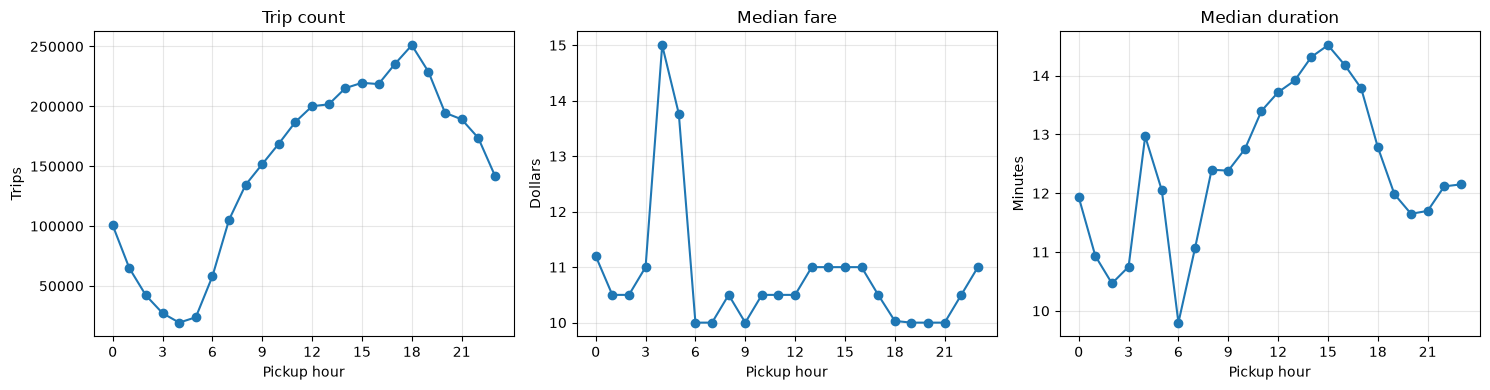

,trips,median_fare,median_duration,median_distance
pickup_hour,,,,
0,100600,11.20,11.93,2.60
1,64819,10.50,10.93,2.48
2,42032,10.50,10.47,2.43
3,27241,11.00,10.75,2.67
4,19348,15.00,12.97,3.69
5,23830,13.76,12.05,3.35
6,58052,10.00,9.80,2.29
7,105216,10.00,11.07,2.08
8,134472,10.50,12.40,1.90


In [26]:
import matplotlib.pyplot as plt

hourly_summary = (
    df.loc[distance_model_mask]
    .assign(
        pickup_hour=lambda x: x["tpep_pickup_datetime"].dt.hour
    )
    .groupby("pickup_hour")
    .agg(
        trips=("fare_amount", "size"),
        median_fare=("fare_amount", "median"),
        median_duration=("duration_minutes", "median"),
        median_distance=("trip_distance", "median"),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, column, title, ylabel in [
    (axes[0], "trips", "Trip count", "Trips"),
    (axes[1], "median_fare", "Median fare", "Dollars"),
    (axes[2], "median_duration", "Median duration", "Minutes"),
]:
    ax.plot(hourly_summary.index, hourly_summary[column], marker="o")
    ax.set(title=title, xlabel="Pickup hour", ylabel=ylabel)
    ax.set_xticks(range(0, 24, 3))
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

display(hourly_summary.round(2))

**Findings:**
- 6 p.m. has the most recorded pickups: 251,065 across the month.
- 3 p.m. has the longest median duration: 14.52 minutes.
- 4 a.m. has the highest median fare ($15) and median distance (3.69 miles), so higher fares may reflect longer trips.

## 9. Day-of-Week Patterns

In [27]:
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday",
]

days_in_month = (
    pd.Series(pd.date_range("2022-05-01", "2022-05-31"))
    .dt.day_name()
    .value_counts()
)

weekday_summary = (
    df.loc[distance_model_mask]
    .assign(
        weekday=lambda x: x["tpep_pickup_datetime"].dt.day_name()
    )
    .groupby("weekday")
    .agg(
        trips=("fare_amount", "size"),
        median_fare=("fare_amount", "median"),
        median_duration=("duration_minutes", "median"),
        median_distance=("trip_distance", "median"),
    )
    .reindex(weekday_order)
)

weekday_summary["avg_trips_per_day"] = (
    weekday_summary["trips"] / days_in_month.reindex(weekday_order)
)

display(weekday_summary.round(2))

,trips,median_fare,median_duration,median_distance,avg_trips_per_day
weekday,,,,,
Monday,505710,10.0,11.93,1.98,101142.00
Tuesday,593149,10.5,13.10,1.90,118629.80
Wednesday,496152,10.5,13.33,1.90,124038.00
Thursday,510252,10.5,13.42,1.91,127563.00
Friday,487598,10.5,13.00,1.90,121899.50
Saturday,462529,10.5,12.38,1.99,115632.25
Sunday,498325,10.5,12.00,2.20,99665.00


Thursday has the most recorded trips per day (127,563) and the longest median duration (13.42 minutes). Sunday has the fewest trips per day (99,665), but the longest median distance (2.20 miles). Median fares vary little across weekdays.

## 10. Distance, Duration, and Fare Relationships

In [28]:
distance_summary = (
    df.loc[distance_model_mask]
    .assign(
        distance_band=lambda x: pd.cut(
            x["trip_distance"],
            bins=[-float("inf"), 0, 1, 2, 5, 10, 20, 100],
            labels=[
                "Zero miles", "Over 0–1", "Over 1–2",
                "Over 2–5", "Over 5–10", "Over 10–20",
                "Over 20–100",
            ],
        )
    )
    .groupby("distance_band", observed=True)
    .agg(
        trips=("fare_amount", "size"),
        median_fare=("fare_amount", "median"),
        median_duration=("duration_minutes", "median"),
    )
)

display(distance_summary.round(2))

,trips,median_fare,median_duration
distance_band,,,
Zero miles,41259,17.0,0.42
Over 0–1,674025,5.5,5.23
Over 1–2,1112847,8.5,9.80
Over 2–5,1067294,13.5,16.65
Over 5–10,338488,24.5,24.72
Over 10–20,280261,52.0,40.22
Over 20–100,39541,52.0,52.03


In [29]:
long_trip_rates = (
    df.loc[distance_model_mask & df["trip_distance"].gt(10)]
    .groupby("RatecodeID", dropna=False)
    .agg(
        trips=("fare_amount", "size"),
        median_fare=("fare_amount", "median"),
        median_distance=("trip_distance", "median"),
        median_duration=("duration_minutes", "median"),
    )
    .sort_values("trips", ascending=False)
)

long_trip_rates["percent_of_long_trips"] = (
    long_trip_rates["trips"] / long_trip_rates["trips"].sum() * 100
)

display(long_trip_rates.round(2))

,trips,median_fare,median_distance,median_duration,percent_of_long_trips
RatecodeID,,,,,
1.0,146148,38.00,11.98,35.27,45.70
2.0,136218,52.00,18.13,49.95,42.59
NaN,15286,52.22,14.50,42.99,4.78
3.0,10100,69.50,17.59,41.24,3.16
5.0,5926,80.00,17.47,44.87,1.85
4.0,3738,72.50,21.82,37.93,1.17
99.0,2385,49.20,15.00,53.20,0.75
6.0,1,5.50,33.00,65.42,0.00


Among trips over 10 miles, rate codes 1 and 2 account for 88.29% of records. Their median fares differ substantially ($38 versus $52). Rate category should be considered when interpreting the relationship between distance and fare.

## 11. Pickup and Drop-off Locations

In [30]:
location_summary = pd.DataFrame({
    "unique_locations": df.loc[
        distance_model_mask, ["PULocationID", "DOLocationID"]
    ].nunique(),
    "missing_values": df.loc[
        distance_model_mask, ["PULocationID", "DOLocationID"]
    ].isna().sum(),
})

display(location_summary)

for column in ["PULocationID", "DOLocationID"]:
    print(f"\nTop 10: {column}")
    display(
        df.loc[distance_model_mask, column]
        .value_counts()
        .head(10)
        .rename_axis("location_id")
        .to_frame("trips")
    )

,unique_locations,missing_values
PULocationID,259,0
DOLocationID,261,0



Top 10: PULocationID


,trips
location_id,
132,172581
237,172409
236,151560
161,137422
142,119541
162,112653
48,110234
230,109051
186,108905



Top 10: DOLocationID


,trips
location_id,
236,154740
237,149528
161,129851
230,105217
170,101958
142,99055
239,97749
48,94702
162,93877


In [31]:
lookup_path = root / "data" / "raw" / "taxi_zone_lookup.csv"

if not lookup_path.exists():
    pd.read_csv(
        "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
    ).to_csv(lookup_path, index=False)

zones = pd.read_csv(lookup_path)

for column, label in [
    ("PULocationID", "TOP PICKUP ZONES"),
    ("DOLocationID", "TOP DROP-OFF ZONES"),
]:
    top_locations = (
        df.loc[distance_model_mask, column]
        .value_counts()
        .head(10)
        .rename_axis("LocationID")
        .reset_index(name="trips")
        .merge(
            zones[["LocationID", "Borough", "Zone"]],
            on="LocationID",
            how="left",
            validate="one_to_one",
        )
    )

    print(label)
    display(top_locations[["LocationID", "Borough", "Zone", "trips"]])

TOP PICKUP ZONES


,LocationID,Borough,Zone,trips
0,132,Queens,JFK Airport,172581
1,237,Manhattan,Upper East Side South,172409
2,236,Manhattan,Upper East Side North,151560
3,161,Manhattan,Midtown Center,137422
4,142,Manhattan,Lincoln Square East,119541
5,162,Manhattan,Midtown East,112653
6,48,Manhattan,Clinton East,110234
7,230,Manhattan,Times Sq/Theatre District,109051
8,186,Manhattan,Penn Station/Madison Sq West,108905
9,170,Manhattan,Murray Hill,107452


TOP DROP-OFF ZONES


,LocationID,Borough,Zone,trips
0,236,Manhattan,Upper East Side North,154740
1,237,Manhattan,Upper East Side South,149528
2,161,Manhattan,Midtown Center,129851
3,230,Manhattan,Times Sq/Theatre District,105217
4,170,Manhattan,Murray Hill,101958
5,142,Manhattan,Lincoln Square East,99055
6,239,Manhattan,Upper West Side South,97749
7,48,Manhattan,Clinton East,94702
8,162,Manhattan,Midtown East,93877
9,141,Manhattan,Lenox Hill West,92580


JFK Airport is the top pickup zone, narrowly ahead of Upper East Side South. Nine of the top ten pickup zones and all top ten drop-off zones are in Manhattan.

### Borough-Level Coverage

In [32]:
for column, label in [
    ("PULocationID", "PICKUPS"),
    ("DOLocationID", "DROP-OFFS"),
]:
    location_counts = (
        df.loc[distance_model_mask, column]
        .value_counts()
        .rename_axis("LocationID")
        .reset_index(name="trips")
        .merge(
            zones[["LocationID", "Borough", "Zone"]],
            on="LocationID",
            how="left",
            validate="one_to_one",
            indicator=True,
        )
    )

    print(f"\n{label}")
    print(
        "Trips with IDs absent from lookup:",
        location_counts.loc[
            location_counts["_merge"].eq("left_only"), "trips"
        ].sum(),
    )

    borough_summary = (
        location_counts
        .assign(Borough=lambda x: x["Borough"].fillna("Unspecified"))
        .groupby("Borough")["trips"]
        .sum()
        .sort_values(ascending=False)
        .to_frame()
    )

    borough_summary["percent"] = (
        borough_summary["trips"] / distance_model_mask.sum() * 100
    ).round(2)

    display(borough_summary)


PICKUPS
Trips with IDs absent from lookup: 0


,trips,percent
Borough,,
Manhattan,3159170,88.90
Queens,314391,8.85
Unknown,38915,1.10
Brooklyn,30260,0.85
Unspecified,5584,0.16
Bronx,4106,0.12
EWR,1042,0.03
Staten Island,247,0.01



DROP-OFFS
Trips with IDs absent from lookup: 0


,trips,percent
Borough,,
Manhattan,3124827,87.93
Queens,214677,6.04
Brooklyn,144219,4.06
Bronx,22108,0.62
Unknown,21912,0.62
Unspecified,12631,0.36
EWR,12427,0.35
Staten Island,914,0.03


The filtered dataset is concentrated in Manhattan. Overall model metrics may therefore hide weaker performance in less represented boroughs. Matching a location ID to the lookup does not guarantee a known geographic location.

### Unclear and Special Zone IDs

In [33]:
unclear_zones = zones.loc[
    zones["Borough"].isna()
    | zones["Borough"].isin(["Unknown", "Unspecified"]),
    ["LocationID", "Borough", "Zone"],
].copy()

for column, label in [
    ("PULocationID", "pickup_trips"),
    ("DOLocationID", "dropoff_trips"),
]:
    counts = df.loc[distance_model_mask, column].value_counts()
    unclear_zones[label] = (
        unclear_zones["LocationID"].map(counts).fillna(0).astype(int)
    )

display(unclear_zones)

,LocationID,Borough,Zone,pickup_trips,dropoff_trips
263,264,Unknown,NaN,38915,21912
264,265,NaN,Outside of NYC,5584,12631


These IDs mean different things:
- 264: unknown location.
- 265: outside NYC—a meaningful category, but not a specific destination.
The bold numbers 263 and 264 at the left are DataFrame row indexes; the actual IDs are in LocationID.

## 12. Train, Validation, and Test Split

In [34]:
pickup = df["tpep_pickup_datetime"]

split_masks = {
    "Train": distance_model_mask & pickup.lt("2022-05-22"),
    "Validation": (
        distance_model_mask
        & pickup.ge("2022-05-22")
        & pickup.lt("2022-05-27")
    ),
    "Test": distance_model_mask & pickup.ge("2022-05-27"),
}

split_summary = pd.DataFrame([
    {
        "split": name,
        "trips": int(mask.sum()),
        "first_pickup": pickup.loc[mask].min(),
        "last_pickup": pickup.loc[mask].max(),
    }
    for name, mask in split_masks.items()
]).set_index("split")

display(split_summary)

,trips,first_pickup,last_pickup
split,,,
Train,2491173,2022-05-01,2022-05-21 23:59:59
Validation,570242,2022-05-22,2022-05-26 23:59:58
Test,492300,2022-05-27,2022-05-31 23:59:59


## 13. Modeling Plan: Targets, Features, and Evaluation

Prediction moment: before the ride begins, with the intended destination known.

Targets:
- Fare: fare_amount (not total_amount).
- Duration: duration_minutes.

Initial candidate inputs:
- Pickup zone: PULocationID.
- Intended destination zone: DOLocationID.
- Pickup hour and weekday derived from the requested pickup time.

Assumptions and limitations:
- Recorded pickup time and destination are proxies for information supplied
  at prediction time.
- Location IDs are categories, not numerical quantities.
- IDs 264 and 265 represent unknown and outside-NYC locations.
- Passenger count and rate code require confirmation of availability
  before including them.

Exclude from initial model inputs:
- Drop-off timestamp and duration-derived speed.
- Fare, total amount, tips, tolls, and recorded payment details.
- Recorded trip_distance: actual distance is only known after the trip.
  A pre-trip route estimate could be added later.

Evaluation:
- Chronological train/validation/test split.
- Fit imputers, encoders, and scalers using training data only.
- Current metrics will describe the filtered trip population.
- May was explored before splitting; final evaluation should ideally
  use an additional untouched period.

## 14. Summary and Next Steps

**Key takeaways from this pass:**
- Data quality is generally good. About 3.6% of trips share a block of five missing fields, and that block lines up exactly with `payment_type = 0`.
- A small number of trips have non-positive duration, zero distance, or non-positive fare; these can be filtered without discarding much of the month.
- Once a 3-hour duration cap and a 100 mph implied-speed check are applied on top of the basic filters, the remaining outliers are a handful of trips, reviewed individually above.
- Fares, durations, and trip volume vary meaningfully by pickup hour and weekday, supporting hour/weekday as candidate features.
- The filtered dataset is heavily concentrated in Manhattan pickups and drop-offs; this is a coverage caveat for any model trained on it.

**Proposed next steps:**
- Review the baseline filters in Section 7 with the team, then freeze them as a single reusable filtering function.
- Re-run this same EDA pass on additional months (`uv run pull_trip_data`) to check whether these patterns and thresholds hold outside May.
- Build first baseline models for `fare_amount` and `duration_minutes` using the pickup zone, drop-off zone, pickup hour, and weekday features identified in Section 13, with the chronological train/validation/test split from Section 12.
- Break out baseline performance by borough, given the Manhattan concentration noted above.
- Revisit whether `passenger_count` and `RatecodeID` can be safely added once their availability at prediction time is confirmed.